# Notebook 01 — Baseline de colorización (OpenCV-DNN, CIE-Lab)

En este cuaderno construimos la **primera versión funcional** de la implementación:

- Partimos de imágenes **originales a color** en `../imgs/I*.jpg`.
- Para cada imagen generamos una versión **en escala de grises** (`I*_gray.jpg`), que simula la entrada real al sistema.
- Aplicamos el modelo de Zhang et al. (vía `cv.dnn`) sobre esa imagen en gris (canal L) para obtener una versión **colorizada** (`I*_color.png`).
- Trabajamos en el espacio **CIE-Lab**: la red recibe L (luminancia) y predice a,b (crominancia); después reconstruimos la imagen en color.

Las salidas (`I*_color.png`) y las imágenes originales (`I*.jpg`) se usarán después en el Notebook 02 para calcular PSNR y SSIM.

In [2]:
from pathlib import Path
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

BASE = Path('..').resolve()
MODELS = BASE / 'models'

DATA_RAW = (BASE / 'imgs')
DATA_RES = (BASE / 'imgs_out')

PROTOTXT   = MODELS / 'colorization_deploy_v2.prototxt'
CAFFEMODEL = MODELS / 'colorization_release_v2.caffemodel'
PTS_NPY    = MODELS / 'pts_in_hull.npy'

print('BASE       =', BASE)
print('RAW (in)   =', DATA_RAW)
print('RES (out)  =', DATA_RES)
print('PROTOTXT   =', PROTOTXT.name)
print('CAFFEMODEL =', CAFFEMODEL.name)
print('PTS_NPY    =', PTS_NPY.name)

BASE       = C:\Users\adria\OneDrive\Escritorio\UNI\PID\Trabajo\PID_colorization
RAW (in)   = C:\Users\adria\OneDrive\Escritorio\UNI\PID\Trabajo\PID_colorization\imgs
RES (out)  = C:\Users\adria\OneDrive\Escritorio\UNI\PID\Trabajo\PID_colorization\imgs_out
PROTOTXT   = colorization_deploy_v2.prototxt
CAFFEMODEL = colorization_release_v2.caffemodel
PTS_NPY    = pts_in_hull.npy


## Función `colorize_bgr`

Esta función implementa el pipeline completo del baseline:

1. Carga la red Caffe de Zhang et al. (`colorization_deploy_v2.prototxt` + `colorization_release_v2.caffemodel`).
2. Inyecta los 313 centros de color (`pts_in_hull.npy`) en la capa `class8_ab` y el vector de re-peso en `conv8_313_rh`.
3. **Preprocesado**:
   - convierte la imagen BGR a RGB y después a Lab normalizado en \[0,1],
   - extrae el canal **L**, lo reescala a 224×224 y centra **L − 50**,
   - construye el *blob* de entrada para `cv.dnn`.
4. **Inferencia** de la red y *upsampling* de los mapas **a,b** a la resolución original.
5. **Reconstrucción**: combina el **L** original con los **a,b** predichos, convierte de Lab a RGB/BGR y devuelve una imagen `uint8`.

Esta misma lógica se ha llevado al script `scripts/colorize_dnn.py` para poder usar el baseline desde línea de comandos.

In [3]:
def colorize_bgr(img_bgr):
    # Cargar red
    net = cv.dnn.readNetFromCaffe(str(PROTOTXT), str(CAFFEMODEL))

    # Inyección de centros ab (313x2) + re-peso
    pts = np.load(str(PTS_NPY)).transpose().reshape(2, 313, 1, 1).astype('float32')
    net.getLayer(net.getLayerId('class8_ab')).blobs = [pts]
    net.getLayer(net.getLayerId('conv8_313_rh')).blobs = [np.full((1,313), 2.606, 'float32')]

    # Preproceso
    img_rgb = cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB).astype('float32') / 255.0
    img_lab = cv.cvtColor(img_rgb, cv.COLOR_RGB2Lab)
    L = img_lab[:, :, 0]

    L_rs = cv.resize(L, (224, 224))
    L_rs -= 50
    blob = cv.dnn.blobFromImage(L_rs)

    # Forward
    net.setInput(blob)
    ab = net.forward()[0].transpose(1, 2, 0)           # H'×W'×2
    ab_up = cv.resize(ab, (img_bgr.shape[1], img_bgr.shape[0]))

    # Reconstrucción
    Lab_out = np.concatenate([L[:, :, None], ab_up], axis=2).astype('float32')
    out_rgb = cv.cvtColor(Lab_out, cv.COLOR_Lab2RGB)
    out_rgb = (np.clip(out_rgb, 0, 1) * 255.0).astype('uint8')
    out_bgr = cv.cvtColor(out_rgb, cv.COLOR_RGB2BGR)
    return out_bgr

### Demostración visual del coloreado (imagen ya en gris)

En esta celda comprobamos el comportamiento del baseline con una imagen de prueba
`ansel_adams.jpg` que **ya está en escala de grises** en `../imgs/`.

Esta imagen NO forma parte del conjunto sobre el que calcularemos métricas; se usa
solo para:

1. Cargar una imagen en gris.
2. Pasarla a BGR para alimentar la red.
3. Visualizar el resultado colorizado.

Más abajo aplicaremos el flujo completo (color → gris → colorizada) sobre nuestras
imágenes de trabajo `imagen01/02/03.jpg`, que sí se usarán para las métricas.

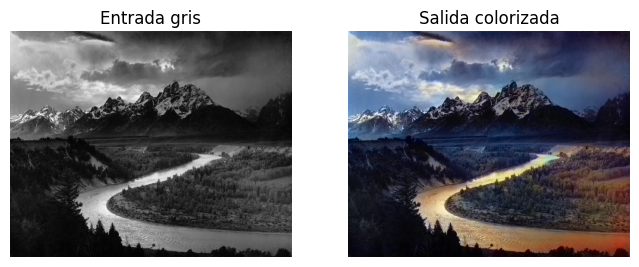

Guardado color -> C:\Users\adria\OneDrive\Escritorio\UNI\PID\Trabajo\PID_colorization\imgs_out\ansel_adams_color.jpg


In [4]:
# Demostración con una imagen de ejemplo ya en gris (ansel_adams.jpg)

gray_path = DATA_RAW / 'ansel_adams.jpg'   # esta imagen está en gris en ../imgs/
img_gray = cv.imread(str(gray_path), cv.IMREAD_GRAYSCALE)
assert img_gray is not None, f'No se encontró la imagen: {gray_path}'

# Convertimos la gris a BGR para alimentar la red
img_gray_bgr = cv.cvtColor(img_gray, cv.COLOR_GRAY2BGR)

# Inferencia
out_bgr = colorize_bgr(img_gray_bgr)

# Guardar salida colorizada (solo demostración, no se usará en métricas)
out_path = DATA_RES / 'ansel_adams_color.jpg'
cv.imwrite(str(out_path), out_bgr)

# Mostrar entrada (gris) y salida (colorizada)
fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].imshow(img_gray, cmap='gray'); ax[0].set_title('Entrada gris'); ax[0].axis('off')
ax[1].imshow(cv.cvtColor(out_bgr, cv.COLOR_BGR2RGB)); ax[1].set_title('Salida colorizada'); ax[1].axis('off')
plt.show()

print('Guardado color ->', out_path)

## Procesado por lotes de todas las imágenes `I*.jpg`

A continuación aplicamos el mismo flujo (color → gris → colorizada) a **todas las imágenes**
del directorio `../imgs/` cuyo nombre empiece por `I`:

- Entrada: `I1.jpg`, `I2.jpg`, … (originales a color).
- Guardamos `I1_gray.jpg`, `I2_gray.jpg`, … (entradas en gris).
- Guardamos `I1_color.jpg`, `I2_color.jpg`, … en `../imgs_out/`.

Estas salidas son las que luego se utilizarán en el Notebook 02 para calcular PSNR y SSIM.

In [3]:
# Colorización por lotes de todas las imágenes I*.jpg

img_paths = sorted(DATA_RAW.glob('I*.jpg'))
print(f'Se han encontrado {len(img_paths)} originales a color en {DATA_RAW}')

for img_path_color in img_paths:
    # Original a color
    img_color_bgr = cv.imread(str(img_path_color))
    if img_color_bgr is None:
        print(f'[AVISO] No se pudo leer {img_path_color}')
        continue

    # Gris
    img_gray = cv.cvtColor(img_color_bgr, cv.COLOR_BGR2GRAY)
    gray_path = DATA_RAW / f'{img_path_color.stem}_gray.jpg'
    cv.imwrite(str(gray_path), img_gray)

    # Colorización desde gris
    img_gray_bgr = cv.cvtColor(img_gray, cv.COLOR_GRAY2BGR)
    out_bgr = colorize_bgr(img_gray_bgr)
    out_path = DATA_RES / f'{img_path_color.stem}_color.jpg'
    cv.imwrite(str(out_path), out_bgr)

    print(f'Procesada {img_path_color.name} -> {gray_path.name} -> {out_path.name}')

print('Proceso por lotes finalizado.')

Se han encontrado 13 originales a color en C:\Users\adria\OneDrive\Escritorio\UNI\PID\Trabajo\PID_colorization\imgs
Procesada Imagen01.jpg -> Imagen01_gray.jpg -> Imagen01_color.jpg
Procesada Imagen02.jpg -> Imagen02_gray.jpg -> Imagen02_color.jpg
Procesada Imagen03.jpg -> Imagen03_gray.jpg -> Imagen03_color.jpg
Procesada Imagen04.jpg -> Imagen04_gray.jpg -> Imagen04_color.jpg
Procesada Imagen05.jpg -> Imagen05_gray.jpg -> Imagen05_color.jpg
Procesada Imagen06.jpg -> Imagen06_gray.jpg -> Imagen06_color.jpg
Procesada Imagen07.jpg -> Imagen07_gray.jpg -> Imagen07_color.jpg
Procesada Imagen08.jpg -> Imagen08_gray.jpg -> Imagen08_color.jpg
Procesada Imagen09.jpg -> Imagen09_gray.jpg -> Imagen09_color.jpg
Procesada Imagen10.jpg -> Imagen10_gray.jpg -> Imagen10_color.jpg
Procesada Imagen11.jpg -> Imagen11_gray.jpg -> Imagen11_color.jpg
Procesada Imagen12.jpg -> Imagen12_gray.jpg -> Imagen12_color.jpg
Procesada Imagen13.jpg -> Imagen13_gray.jpg -> Imagen13_color.jpg
Proceso por lotes finaliza